In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LIBRARIES

In [54]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
import torch.optim as optim
from torch.utils.data import DataLoader
#from torchsummary import summary
import matplotlib.pyplot as plt

INPUTS

In [55]:
IMG_HEIGHT= 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
CLASS_NAMES = ["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [56]:
transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dir ="/content/drive/MyDrive/flower_images/train"
val_dir = "/content/drive/MyDrive/flower_images/val"

train_data= datasets.ImageFolder(root=train_dir, transform=transform)
val_data= datasets.ImageFolder(root=val_dir, transform= val_transform)

train_dataset = DataLoader(train_data, batch_size=16, shuffle=True)
val_dataset = DataLoader(val_data, batch_size=16, shuffle=True)

NETWORK ARCHITECTURE

In [57]:
model = models.vgg16(pretrained = True)

for params in model.parameters():
    params.requires_grad=False

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(4096, 5)
)

for params in model.classifier[-1].parameters():
    params.requires_grad=True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [58]:
learning_rate= 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [59]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    train_loss =[]
    train_accuracy=[]
    val_loss=[]
    val_accuracy =[]
    for epoch in range(epochs):
        model.train()

        correct_preds = 0
        total_loss =0
        total_samples =0


        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs =model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _,preds = torch.max(outputs,1)
            batch_preds = (preds==labels).sum().item()
            correct_preds +=batch_preds
            total_loss +=loss.item()
            total_samples+=labels.size(0)

        train_acc = correct_preds/total_samples
        print(f"Epoch: {epoch+1} ==> Loss: {total_loss:.4f}, Accuracy: {train_acc:.4f}")
        train_loss.append(total_loss)
        train_accuracy.append(train_acc)
        model.eval()
        val_preds = 0
        eval_loss = 0
        val_samples=0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_preds += (preds==labels).sum().item()
                eval_loss += loss.item()
                val_samples += labels.size(0)

        val_acc = val_preds/val_samples
        print(f"Validation Loss: {eval_loss:.4f}, Validation Accuracy: {val_acc:.4f}")
        val_loss.append(eval_loss)
        val_accuracy.append(val_acc)
    return train_loss, train_accuracy, val_loss, val_accuracy

TRAINING

In [60]:
EPOCHS=10
train_loss, train_acc, val_loss, val_acc= train_model(model, criterion, optimizer, train_dataset, val_dataset, EPOCHS, device)

Epoch: 1 ==> Loss: 222.5878, Accuracy: 0.6990
Validation Loss: 105.6090, Validation Accuracy: 0.7550
Epoch: 2 ==> Loss: 118.5932, Accuracy: 0.8387
Validation Loss: 10.0792, Validation Accuracy: 0.8610
Epoch: 3 ==> Loss: 170.5323, Accuracy: 0.8473
Validation Loss: 31.5083, Validation Accuracy: 0.8220
Epoch: 4 ==> Loss: 181.5774, Accuracy: 0.8713
Validation Loss: 58.9850, Validation Accuracy: 0.8760
Epoch: 5 ==> Loss: 146.2473, Accuracy: 0.8930
Validation Loss: 2.9050, Validation Accuracy: 0.8680
Epoch: 6 ==> Loss: 165.1993, Accuracy: 0.9057
Validation Loss: 586.6745, Validation Accuracy: 0.8840
Epoch: 7 ==> Loss: 147.3766, Accuracy: 0.9213
Validation Loss: 91.0321, Validation Accuracy: 0.8880
Epoch: 8 ==> Loss: 207.7340, Accuracy: 0.9113
Validation Loss: 36.5589, Validation Accuracy: 0.8590
Epoch: 9 ==> Loss: 226.4739, Accuracy: 0.9257
Validation Loss: 0.0284, Validation Accuracy: 0.8900
Epoch: 10 ==> Loss: 259.5575, Accuracy: 0.9197
Validation Loss: 0.0000, Validation Accuracy: 0.9020


PLOTTING

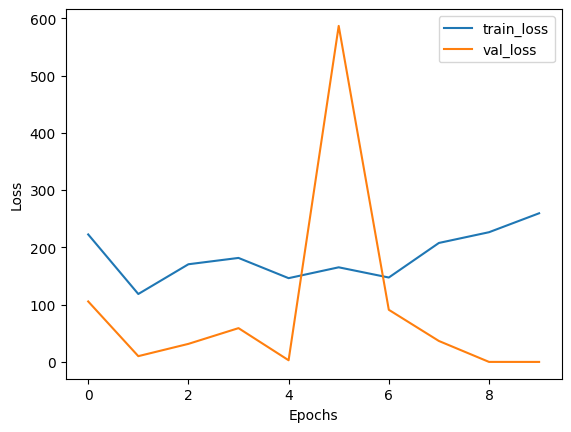

In [62]:
plt.plot(train_loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

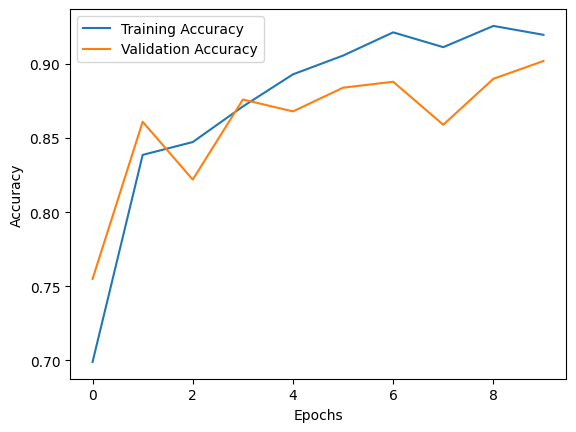

In [64]:
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()